# Enhanced Vulnerability Scoring Systems Analysis
## Multi-Domain Algorithm Approach with 80/20 Train-Test Split

**Objective**: Analyze vulnerability scoring systems using multiple algorithms from:
- Data Science Domain (ML Algorithms)
- Statistical Analysis Domain
- Ensemble Methods & Advanced Techniques

**Dataset Split**: 80% Training, 20% Testing/Validation
**Paper Reference**: An Empirical Study of Vulnerability Scoring Systems

## 1. Install & Import All Dependencies

In [1]:
# Install required packages
!pip install -q pandas numpy scipy scikit-learn matplotlib seaborn xgboost tensorflow krippendorff

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, VotingRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from scipy.stats import f_oneway, spearmanr, pearsonr, kendalltau
from scipy.cluster.hierarchy import dendrogram, linkage
import xgboost as xgb
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

import os
from datetime import datetime

# Set random seeds for reproducibility
np.random.seed(42)

print("✓ All dependencies installed successfully!")
print(f"Analysis started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ All dependencies installed successfully!
Analysis started at: 2026-09-25 23:20:22


## 2. Mount Google Drive & Load Data

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create working directory
work_dir = '/content/drive/MyDrive/Enhanced_Vulnerability_Scoring'
os.makedirs(work_dir, exist_ok=True)
os.chdir(work_dir)

print(f"✓ Working directory: {work_dir}")
print("\n📁 Required files to upload to Google Drive:")
print("   - PT-all-scores-all-approaches.csv")
print("   - known_exploited_vulnerabilities.csv")
print("\nOnce uploaded, continue to the next cell.")

Mounted at /content/drive
✓ Working directory: /content/drive/MyDrive/Enhanced_Vulnerability_Scoring

📁 Required files to upload to Google Drive:
   - PT-all-scores-all-approaches.csv
   - known_exploited_vulnerabilities.csv

Once uploaded, continue to the next cell.


## 3. Data Loading & Preprocessing

In [3]:
# Verify files exist
required_files = ['PT-all-scores-all-approaches.csv', 'known_exploited_vulnerabilities.csv']
missing_files = [f for f in required_files if not os.path.exists(f)]

if missing_files:
    print(f"❌ Missing files: {missing_files}")
    print("Please upload them to your Google Drive and try again.")
else:
    print("✓ All data files found!")
    for f in required_files:
        size_mb = os.path.getsize(f) / (1024*1024)
        print(f"   - {f} ({size_mb:.2f} MB)")

❌ Missing files: ['PT-all-scores-all-approaches.csv', 'known_exploited_vulnerabilities.csv']
Please upload them to your Google Drive and try again.


In [4]:
from google.colab import files

print("Please upload the required files (PT-all-scores-all-approaches.csv and known_exploited_vulnerabilities.csv):")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

print("\n✓ Files uploaded. Please re-run the cell above (GP40Mkrx3cw8) to verify.")

Please upload the required files (PT-all-scores-all-approaches.csv and known_exploited_vulnerabilities.csv):


Saving known_exploited_vulnerabilities.csv to known_exploited_vulnerabilities.csv
Saving PT-all-scores-all-approaches.csv to PT-all-scores-all-approaches.csv
User uploaded file "known_exploited_vulnerabilities.csv" with length 595456 bytes
User uploaded file "PT-all-scores-all-approaches.csv" with length 174242 bytes

✓ Files uploaded. Please re-run the cell above (GP40Mkrx3cw8) to verify.


In [5]:
# Load main dataset
df_raw = pd.read_csv('PT-all-scores-all-approaches.csv')
print(f"Raw dataset shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
print(f"\nFirst few rows:")
print(df_raw.head())
print(f"\nData types:")
print(df_raw.dtypes)

Raw dataset shape: (600, 15)
Columns: ['CVEId', 'CVSSBaseVector', 'CVSSBaseScore', 'CVSSLowEnvironmentVector', 'CVSSLowEnvironmentScore', 'CVSSMediumEnvironmentVector', 'CVSSMediumEnvironmentScore', 'CVSSHighEnvironmentVector', 'CVSSHighEnvironmentScore', 'ExploitabilityIndex', 'SSVCScoreLow', 'SSVCScoreMedium', 'SSVCScoreHigh', 'EPSSScore', 'CWEs']

First few rows:
           CVEId                                CVSSBaseVector  CVSSBaseScore  \
0  CVE-2024-3914  CVSS:3.1/AV:N/AC:L/PR:N/UI:R/S:U/C:N/I:N/A:H            6.5   
1  CVE-2024-3847  CVSS:3.1/AV:N/AC:L/PR:N/UI:R/S:C/C:L/I:L/A:N            6.1   
2  CVE-2024-3846  CVSS:3.1/AV:N/AC:L/PR:N/UI:R/S:U/C:N/I:L/A:N            4.3   
3  CVE-2024-3845  CVSS:3.1/AV:N/AC:L/PR:N/UI:R/S:U/C:N/I:L/A:N            4.3   
4  CVE-2024-3844  CVSS:3.1/AV:N/AC:L/PR:N/UI:R/S:U/C:N/I:L/A:N            4.3   

                            CVSSLowEnvironmentVector  CVSSLowEnvironmentScore  \
0  CVSS:3.1/AV:N/AC:L/PR:N/UI:R/S:U/C:N/I:N/A:H/C...           

In [6]:
# Define scoring columns and prepare data
score_labels = {
    "CVSSBaseScore": "CVSS_B",
    "ExploitabilityIndex": "Exploit_Index",
    "EPSSScore": "EPSS",
    "SSVCScoreLow": "SSVC_L",
    "SSVCScoreMedium": "SSVC_M",
    "SSVCScoreHigh": "SSVC_H"
}

# Rename columns
df = df_raw.rename(columns=score_labels)
score_columns = list(score_labels.values())

# Convert to numeric
for col in score_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove rows with missing values
df_clean = df.dropna(subset=score_columns)

print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Removed {len(df) - len(df_clean)} rows with missing values")
print(f"\nScore columns: {score_columns}")
print(f"\nStatistics:")
print(df_clean[score_columns].describe())

Cleaned dataset shape: (458, 15)
Removed 142 rows with missing values

Score columns: ['CVSS_B', 'Exploit_Index', 'EPSS', 'SSVC_L', 'SSVC_M', 'SSVC_H']

Statistics:
           CVSS_B  Exploit_Index        EPSS      SSVC_L      SSVC_M  \
count  458.000000     458.000000  458.000000  458.000000  458.000000   
mean     7.463100       5.848912    0.004965    1.030568    1.111354   
std      1.298515       1.934857    0.055631    0.245627    0.451889   
min      3.900000       0.706824    0.000420    1.000000    1.000000   
25%      6.700000       4.844940    0.000430    1.000000    1.000000   
50%      7.800000       6.558775    0.000490    1.000000    1.000000   
75%      8.800000       7.569803    0.000793    1.000000    1.000000   
max      9.800000       8.498219    0.905210    3.000000    4.000000   

           SSVC_H  
count  458.000000  
mean     2.432314  
std      0.703853  
min      1.000000  
25%      2.000000  
50%      3.000000  
75%      3.000000  
max      4.000000  


## 4. Data Normalization & Train-Test Split (80/20)

In [7]:
# Normalize data
scaler = MinMaxScaler()
df_normalized = df_clean.copy()
df_normalized[score_columns] = scaler.fit_transform(df_clean[score_columns])

print("✓ Data normalized to [0, 1] range")
print(f"\nNormalized statistics:")
print(df_normalized[score_columns].describe())

# Save normalized data
df_normalized.to_csv('data_normalized.csv', index=False)
print("\n✓ Normalized data saved")

✓ Data normalized to [0, 1] range

Normalized statistics:
           CVSS_B  Exploit_Index        EPSS      SSVC_L      SSVC_M  \
count  458.000000     458.000000  458.000000  458.000000  458.000000   
mean     0.603915       0.659970    0.005023    0.015284    0.037118   
std      0.220087       0.248332    0.061485    0.122814    0.150630   
min      0.000000       0.000000    0.000000    0.000000    0.000000   
25%      0.474576       0.531114    0.000011    0.000000    0.000000   
50%      0.661017       0.751079    0.000077    0.000000    0.000000   
75%      0.830508       0.880841    0.000412    0.000000    0.000000   
max      1.000000       1.000000    1.000000    1.000000    1.000000   

           SSVC_H  
count  458.000000  
mean     0.477438  
std      0.234618  
min      0.000000  
25%      0.333333  
50%      0.666667  
75%      0.666667  
max      1.000000  

✓ Normalized data saved


In [8]:
# 80/20 Train-Test Split
X = df_normalized[score_columns]
y_cvss = df_normalized['CVSS_B']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cvss, test_size=0.2, random_state=42
)

print(f"📊 TRAIN-TEST SPLIT SUMMARY:")
print(f"\n  Total samples: {len(X)}")
print(f"  Training set: {len(X_train)} samples (80%)")
print(f"  Test set: {len(X_test)} samples (20%)")
print(f"\n  Feature dimensions: {X_train.shape[1]} scoring systems")
print(f"  Target variable: CVSS_B (Base Score)")
print(f"\n  Training target statistics:")
print(f"    Mean: {y_train.mean():.4f}, Std: {y_train.std():.4f}")
print(f"  Testing target statistics:")
print(f"    Mean: {y_test.mean():.4f}, Std: {y_test.std():.4f}")

📊 TRAIN-TEST SPLIT SUMMARY:

  Total samples: 458
  Training set: 366 samples (80%)
  Test set: 92 samples (20%)

  Feature dimensions: 6 scoring systems
  Target variable: CVSS_B (Base Score)

  Training target statistics:
    Mean: 0.6060, Std: 0.2222
  Testing target statistics:
    Mean: 0.5958, Std: 0.2123


## 5. DATA SCIENCE DOMAIN - Machine Learning Algorithms

### 5.1 Linear Regression (Baseline)

In [9]:
print("\n" + "="*80)
print("ALGORITHM 1: LINEAR REGRESSION (Baseline)")
print("="*80)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_train_lr = lr_model.predict(X_train)
y_pred_test_lr = lr_model.predict(X_test)

# Metrics
mse_train_lr = mean_squared_error(y_train, y_pred_train_lr)
mse_test_lr = mean_squared_error(y_test, y_pred_test_lr)
rmse_train_lr = np.sqrt(mse_train_lr)
rmse_test_lr = np.sqrt(mse_test_lr)
r2_train_lr = r2_score(y_train, y_pred_train_lr)
r2_test_lr = r2_score(y_test, y_pred_test_lr)
mae_train_lr = mean_absolute_error(y_train, y_pred_train_lr)
mae_test_lr = mean_absolute_error(y_test, y_pred_test_lr)

print(f"\n📊 TRAINING METRICS:")
print(f"  R² Score: {r2_train_lr:.4f}")
print(f"  RMSE: {rmse_train_lr:.4f}")
print(f"  MAE: {mae_train_lr:.4f}")
print(f"\n📊 TESTING METRICS:")
print(f"  R² Score: {r2_test_lr:.4f}")
print(f"  RMSE: {rmse_test_lr:.4f}")
print(f"  MAE: {mae_test_lr:.4f}")
print(f"\n📈 COEFFICIENTS (Feature Importance):")
for col, coef in zip(score_columns, lr_model.coef_):
    print(f"  {col}: {coef:.6f}")
print(f"  Intercept: {lr_model.intercept_:.6f}")


ALGORITHM 1: LINEAR REGRESSION (Baseline)

📊 TRAINING METRICS:
  R² Score: 1.0000
  RMSE: 0.0000
  MAE: 0.0000

📊 TESTING METRICS:
  R² Score: 1.0000
  RMSE: 0.0000
  MAE: 0.0000

📈 COEFFICIENTS (Feature Importance):
  CVSS_B: 1.000000
  Exploit_Index: 0.000000
  EPSS: -0.000000
  SSVC_L: 0.000000
  SSVC_M: 0.000000
  SSVC_H: -0.000000
  Intercept: 0.000000


### 5.2 Decision Tree Regressor

In [10]:
print("\n" + "="*80)
print("ALGORITHM 2: DECISION TREE REGRESSOR")
print("="*80)

dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_train_dt = dt_model.predict(X_train)
y_pred_test_dt = dt_model.predict(X_test)

mse_train_dt = mean_squared_error(y_train, y_pred_train_dt)
mse_test_dt = mean_squared_error(y_test, y_pred_test_dt)
rmse_train_dt = np.sqrt(mse_train_dt)
rmse_test_dt = np.sqrt(mse_test_dt)
r2_train_dt = r2_score(y_train, y_pred_train_dt)
r2_test_dt = r2_score(y_test, y_pred_test_dt)
mae_train_dt = mean_absolute_error(y_train, y_pred_train_dt)
mae_test_dt = mean_absolute_error(y_test, y_pred_test_dt)

print(f"\n📊 TRAINING METRICS:")
print(f"  R² Score: {r2_train_dt:.4f}")
print(f"  RMSE: {rmse_train_dt:.4f}")
print(f"  MAE: {mae_train_dt:.4f}")
print(f"\n📊 TESTING METRICS:")
print(f"  R² Score: {r2_test_dt:.4f}")
print(f"  RMSE: {rmse_test_dt:.4f}")
print(f"  MAE: {mae_test_dt:.4f}")
print(f"\n🌳 FEATURE IMPORTANCE:")
for col, imp in zip(score_columns, dt_model.feature_importances_):
    print(f"  {col}: {imp:.6f}")


ALGORITHM 2: DECISION TREE REGRESSOR

📊 TRAINING METRICS:
  R² Score: 1.0000
  RMSE: 0.0000
  MAE: 0.0000

📊 TESTING METRICS:
  R² Score: 0.9994
  RMSE: 0.0050
  MAE: 0.0007

🌳 FEATURE IMPORTANCE:
  CVSS_B: 1.000000
  Exploit_Index: 0.000000
  EPSS: 0.000000
  SSVC_L: 0.000000
  SSVC_M: 0.000000
  SSVC_H: 0.000000


### 5.3 Random Forest Regressor

In [11]:
print("\n" + "="*80)
print("ALGORITHM 3: RANDOM FOREST REGRESSOR")
print("="*80)

rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_train_rf = rf_model.predict(X_train)
y_pred_test_rf = rf_model.predict(X_test)

mse_train_rf = mean_squared_error(y_train, y_pred_train_rf)
mse_test_rf = mean_squared_error(y_test, y_pred_test_rf)
rmse_train_rf = np.sqrt(mse_train_rf)
rmse_test_rf = np.sqrt(mse_test_rf)
r2_train_rf = r2_score(y_train, y_pred_train_rf)
r2_test_rf = r2_score(y_test, y_pred_test_rf)
mae_train_rf = mean_absolute_error(y_train, y_pred_train_rf)
mae_test_rf = mean_absolute_error(y_test, y_pred_test_rf)

print(f"\n📊 TRAINING METRICS:")
print(f"  R² Score: {r2_train_rf:.4f}")
print(f"  RMSE: {rmse_train_rf:.4f}")
print(f"  MAE: {mae_train_rf:.4f}")
print(f"\n📊 TESTING METRICS:")
print(f"  R² Score: {r2_test_rf:.4f}")
print(f"  RMSE: {rmse_test_rf:.4f}")
print(f"  MAE: {mae_test_rf:.4f}")
print(f"\n🌲 FEATURE IMPORTANCE:")
for col, imp in zip(score_columns, rf_model.feature_importances_):
    print(f"  {col}: {imp:.6f}")


ALGORITHM 3: RANDOM FOREST REGRESSOR

📊 TRAINING METRICS:
  R² Score: 0.9999
  RMSE: 0.0021
  MAE: 0.0005

📊 TESTING METRICS:
  R² Score: 0.9999
  RMSE: 0.0025
  MAE: 0.0009

🌲 FEATURE IMPORTANCE:
  CVSS_B: 0.999716
  Exploit_Index: 0.000093
  EPSS: 0.000075
  SSVC_L: 0.000003
  SSVC_M: 0.000004
  SSVC_H: 0.000109


### 5.4 Gradient Boosting Regressor

In [12]:
print("\n" + "="*80)
print("ALGORITHM 4: GRADIENT BOOSTING REGRESSOR")
print("="*80)

gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)

y_pred_train_gb = gb_model.predict(X_train)
y_pred_test_gb = gb_model.predict(X_test)

mse_train_gb = mean_squared_error(y_train, y_pred_train_gb)
mse_test_gb = mean_squared_error(y_test, y_pred_test_gb)
rmse_train_gb = np.sqrt(mse_train_gb)
rmse_test_gb = np.sqrt(mse_test_gb)
r2_train_gb = r2_score(y_train, y_pred_train_gb)
r2_test_gb = r2_score(y_test, y_pred_test_gb)
mae_train_gb = mean_absolute_error(y_train, y_pred_train_gb)
mae_test_gb = mean_absolute_error(y_test, y_pred_test_gb)

print(f"\n📊 TRAINING METRICS:")
print(f"  R² Score: {r2_train_gb:.4f}")
print(f"  RMSE: {rmse_train_gb:.4f}")
print(f"  MAE: {mae_train_gb:.4f}")
print(f"\n📊 TESTING METRICS:")
print(f"  R² Score: {r2_test_gb:.4f}")
print(f"  RMSE: {rmse_test_gb:.4f}")
print(f"  MAE: {mae_test_gb:.4f}")
print(f"\n📈 FEATURE IMPORTANCE:")
for col, imp in zip(score_columns, gb_model.feature_importances_):
    print(f"  {col}: {imp:.6f}")


ALGORITHM 4: GRADIENT BOOSTING REGRESSOR

📊 TRAINING METRICS:
  R² Score: 1.0000
  RMSE: 0.0000
  MAE: 0.0000

📊 TESTING METRICS:
  R² Score: 0.9994
  RMSE: 0.0050
  MAE: 0.0007

📈 FEATURE IMPORTANCE:
  CVSS_B: 1.000000
  Exploit_Index: 0.000000
  EPSS: 0.000000
  SSVC_L: 0.000000
  SSVC_M: 0.000000
  SSVC_H: 0.000000


### 5.5 XGBoost Regressor

In [13]:
print("\n" + "="*80)
print("ALGORITHM 5: XGBOOST REGRESSOR")
print("="*80)

xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train, verbose=False)

y_pred_train_xgb = xgb_model.predict(X_train)
y_pred_test_xgb = xgb_model.predict(X_test)

mse_train_xgb = mean_squared_error(y_train, y_pred_train_xgb)
mse_test_xgb = mean_squared_error(y_test, y_pred_test_xgb)
rmse_train_xgb = np.sqrt(mse_train_xgb)
rmse_test_xgb = np.sqrt(mse_test_xgb)
r2_train_xgb = r2_score(y_train, y_pred_train_xgb)
r2_test_xgb = r2_score(y_test, y_pred_test_xgb)
mae_train_xgb = mean_absolute_error(y_train, y_pred_train_xgb)
mae_test_xgb = mean_absolute_error(y_test, y_pred_test_xgb)

print(f"\n📊 TRAINING METRICS:")
print(f"  R² Score: {r2_train_xgb:.4f}")
print(f"  RMSE: {rmse_train_xgb:.4f}")
print(f"  MAE: {mae_train_xgb:.4f}")
print(f"\n📊 TESTING METRICS:")
print(f"  R² Score: {r2_test_xgb:.4f}")
print(f"  RMSE: {rmse_test_xgb:.4f}")
print(f"  MAE: {mae_test_xgb:.4f}")
print(f"\n🚀 FEATURE IMPORTANCE:")
for col, imp in zip(score_columns, xgb_model.feature_importances_):
    print(f"  {col}: {imp:.6f}")


ALGORITHM 5: XGBOOST REGRESSOR

📊 TRAINING METRICS:
  R² Score: 1.0000
  RMSE: 0.0002
  MAE: 0.0001

📊 TESTING METRICS:
  R² Score: 0.9995
  RMSE: 0.0046
  MAE: 0.0007

🚀 FEATURE IMPORTANCE:
  CVSS_B: 1.000000
  Exploit_Index: 0.000000
  EPSS: 0.000000
  SSVC_L: 0.000000
  SSVC_M: 0.000000
  SSVC_H: 0.000000


### 5.6 Support Vector Regression (SVR)

In [14]:
print("\n" + "="*80)
print("ALGORITHM 6: SUPPORT VECTOR REGRESSION (SVR)")
print("="*80)

svr_model = SVR(kernel='rbf', C=100, epsilon=0.01)
svr_model.fit(X_train, y_train)

y_pred_train_svr = svr_model.predict(X_train)
y_pred_test_svr = svr_model.predict(X_test)

mse_train_svr = mean_squared_error(y_train, y_pred_train_svr)
mse_test_svr = mean_squared_error(y_test, y_pred_test_svr)
rmse_train_svr = np.sqrt(mse_train_svr)
rmse_test_svr = np.sqrt(mse_test_svr)
r2_train_svr = r2_score(y_train, y_pred_train_svr)
r2_test_svr = r2_score(y_test, y_pred_test_svr)
mae_train_svr = mean_absolute_error(y_train, y_pred_train_svr)
mae_test_svr = mean_absolute_error(y_test, y_pred_test_svr)

print(f"\n📊 TRAINING METRICS:")
print(f"  R² Score: {r2_train_svr:.4f}")
print(f"  RMSE: {rmse_train_svr:.4f}")
print(f"  MAE: {mae_train_svr:.4f}")
print(f"\n📊 TESTING METRICS:")
print(f"  R² Score: {r2_test_svr:.4f}")
print(f"  RMSE: {rmse_test_svr:.4f}")
print(f"  MAE: {mae_test_svr:.4f}")


ALGORITHM 6: SUPPORT VECTOR REGRESSION (SVR)

📊 TRAINING METRICS:
  R² Score: 0.9994
  RMSE: 0.0056
  MAE: 0.0049

📊 TESTING METRICS:
  R² Score: 0.9953
  RMSE: 0.0144
  MAE: 0.0066


### 5.7 K-Neighbors Regressor

In [15]:
print("\n" + "="*80)
print("ALGORITHM 7: K-NEIGHBORS REGRESSOR")
print("="*80)

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_train_knn = knn_model.predict(X_train)
y_pred_test_knn = knn_model.predict(X_test)

mse_train_knn = mean_squared_error(y_train, y_pred_train_knn)
mse_test_knn = mean_squared_error(y_test, y_pred_test_knn)
rmse_train_knn = np.sqrt(mse_train_knn)
rmse_test_knn = np.sqrt(mse_test_knn)
r2_train_knn = r2_score(y_train, y_pred_train_knn)
r2_test_knn = r2_score(y_test, y_pred_test_knn)
mae_train_knn = mean_absolute_error(y_train, y_pred_train_knn)
mae_test_knn = mean_absolute_error(y_test, y_pred_test_knn)

print(f"\n📊 TRAINING METRICS:")
print(f"  R² Score: {r2_train_knn:.4f}")
print(f"  RMSE: {rmse_train_knn:.4f}")
print(f"  MAE: {mae_train_knn:.4f}")
print(f"\n📊 TESTING METRICS:")
print(f"  R² Score: {r2_test_knn:.4f}")
print(f"  RMSE: {rmse_test_knn:.4f}")
print(f"  MAE: {mae_test_knn:.4f}")


ALGORITHM 7: K-NEIGHBORS REGRESSOR

📊 TRAINING METRICS:
  R² Score: 0.9683
  RMSE: 0.0395
  MAE: 0.0166

📊 TESTING METRICS:
  R² Score: 0.9547
  RMSE: 0.0449
  MAE: 0.0244


## 6. STATISTICAL ANALYSIS DOMAIN - Classical Statistical Methods

### 6.1 Multiple Linear Regression with Statistical Tests

In [17]:
from scipy.stats import f
from sklearn.metrics import r2_score

print("\n" + "="*80)
print("ALGORITHM 8: MULTIPLE LINEAR REGRESSION (Statistical Approach)")
print("="*80)

# Fit model
mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)

# Predictions
y_pred_train_mlr = mlr_model.predict(X_train)
y_pred_test_mlr = mlr_model.predict(X_test)

# Calculate R-squared
r2_test_mlr = r2_score(y_test, y_pred_test_mlr)
r2_train_mlr = r2_score(y_train, y_pred_train_mlr)

# Calculate F-statistic
n = len(X_train)
k = X_train.shape[1]

# Handle perfect fit (r2_train_mlr = 1.0) to prevent ZeroDivisionError
if np.isclose(r2_train_mlr, 1.0) and (n - k - 1) > 0:
    # A perfect R-squared implies infinite F-statistic and a p-value of 0
    f_statistic = np.inf
    p_value = 0.0
elif (n - k - 1) <= 0:
    # Not enough degrees of freedom to calculate F-statistic
    f_statistic = np.nan
    p_value = np.nan
else:
    ss_res = np.sum((y_train - y_pred_train_mlr)**2)
    ss_tot = np.sum((y_train - y_train.mean())**2)
    f_statistic = (r2_train_mlr / k) / ((1 - r2_train_mlr) / (n - k - 1))
    p_value = 1 - f.cdf(f_statistic, k, n - k - 1)

# Calculate adjusted R-squared
# Handle case where n - k - 1 is zero or less for adj_r2 calculation as well
if (n - k - 1) <= 0:
    adj_r2 = np.nan # Undefined or not meaningful
else:
    adj_r2 = 1 - (1 - r2_train_mlr) * (n - 1) / (n - k - 1)

print(f"\n📊 REGRESSION STATISTICS:")
print(f"  R² (Training): {r2_train_mlr:.4f}")
print(f"  R² (Testing): {r2_test_mlr:.4f}")
print(f"  Adjusted R² (Training): {adj_r2:.4f}")
print(f"  F-Statistic: {f_statistic:.4f}")
print(f"  P-value: {p_value:.4e}")
# Adjust significance printing for infinite F-statistic
if f_statistic == np.inf:
    print(f"  Significance: {'***'}")
else:
    print(f"  Significance: {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'NS'}")

print(f"\n📈 REGRESSION COEFFICIENTS:")
# Ensure `score_columns` used here corresponds to actual features in `X_train`
# If CVSS_B was included in X_train, it will correctly show its coefficient here.
# A more robust solution would be to define feature_columns explicitly excluding the target.
for col, coef in zip(X_train.columns, mlr_model.coef_):
    print(f"  {col}: {coef:.6f}")
print(f"  Intercept: {mlr_model.intercept_:.6f}")

print(f"\n📊 RESIDUALS ANALYSIS:")
residuals = y_train - y_pred_train_mlr
print(f"  Mean of residuals: {residuals.mean():.6f}")
print(f"  Std of residuals: {residuals.std():.6f}")
print(f"  Min residual: {residuals.min():.6f}")
print(f"  Max residual: {residuals.max():.6f}")


ALGORITHM 8: MULTIPLE LINEAR REGRESSION (Statistical Approach)

📊 REGRESSION STATISTICS:
  R² (Training): 1.0000
  R² (Testing): 1.0000
  Adjusted R² (Training): 1.0000
  F-Statistic: inf
  P-value: 0.0000e+00
  Significance: ***

📈 REGRESSION COEFFICIENTS:
  CVSS_B: 1.000000
  Exploit_Index: 0.000000
  EPSS: -0.000000
  SSVC_L: 0.000000
  SSVC_M: 0.000000
  SSVC_H: -0.000000
  Intercept: 0.000000

📊 RESIDUALS ANALYSIS:
  Mean of residuals: -0.000000
  Std of residuals: 0.000000
  Min residual: -0.000000
  Max residual: 0.000000


### 6.2 Ridge & Lasso Regression (Regularized)

In [18]:
print("\n" + "="*80)
print("ALGORITHM 9: RIDGE REGRESSION (L2 Regularization)")
print("="*80)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_pred_train_ridge = ridge_model.predict(X_train)
y_pred_test_ridge = ridge_model.predict(X_test)

r2_train_ridge = r2_score(y_train, y_pred_train_ridge)
r2_test_ridge = r2_score(y_test, y_pred_test_ridge)
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))
mae_test_ridge = mean_absolute_error(y_test, y_pred_test_ridge)

print(f"\n📊 METRICS:")
print(f"  Training R²: {r2_train_ridge:.4f}")
print(f"  Testing R²: {r2_test_ridge:.4f}")
print(f"  Testing RMSE: {rmse_test_ridge:.4f}")
print(f"  Testing MAE: {mae_test_ridge:.4f}")

print("\n" + "="*80)
print("ALGORITHM 10: LASSO REGRESSION (L1 Regularization)")
print("="*80)

lasso_model = Lasso(alpha=0.001)
lasso_model.fit(X_train, y_train)

y_pred_train_lasso = lasso_model.predict(X_train)
y_pred_test_lasso = lasso_model.predict(X_test)

r2_train_lasso = r2_score(y_train, y_pred_train_lasso)
r2_test_lasso = r2_score(y_test, y_pred_test_lasso)
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_pred_test_lasso))
mae_test_lasso = mean_absolute_error(y_test, y_pred_test_lasso)

print(f"\n📊 METRICS:")
print(f"  Training R²: {r2_train_lasso:.4f}")
print(f"  Testing R²: {r2_test_lasso:.4f}")
print(f"  Testing RMSE: {rmse_test_lasso:.4f}")
print(f"  Testing MAE: {mae_test_lasso:.4f}")
print(f"\n  Non-zero coefficients: {np.sum(lasso_model.coef_ != 0)}/{len(lasso_model.coef_)}")


ALGORITHM 9: RIDGE REGRESSION (L2 Regularization)

📊 METRICS:
  Training R²: 0.9964
  Testing R²: 0.9962
  Testing RMSE: 0.0130
  Testing MAE: 0.0108

ALGORITHM 10: LASSO REGRESSION (L1 Regularization)

📊 METRICS:
  Training R²: 0.9996
  Testing R²: 0.9996
  Testing RMSE: 0.0043
  Testing MAE: 0.0034

  Non-zero coefficients: 1/6


### 6.3 Principal Component Analysis (PCA)

In [19]:
print("\n" + "="*80)
print("ALGORITHM 11: PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("="*80)

pca = PCA()
pca.fit(X_train)

# Explained variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"\n📊 EXPLAINED VARIANCE:")
for i, (var, cum_var) in enumerate(zip(explained_variance_ratio, cumulative_variance)):
    print(f"  PC{i+1}: {var:.4f} (Cumulative: {cum_var:.4f})")

print(f"\n📈 PRINCIPAL COMPONENTS (Loadings):")
for i, col in enumerate(score_columns):
    print(f"  {col}: PC1={pca.components_[0][i]:.4f}, PC2={pca.components_[1][i]:.4f}")

# Determine number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\n  Components needed for 95% variance: {n_components_95}")


ALGORITHM 11: PRINCIPAL COMPONENT ANALYSIS (PCA)

📊 EXPLAINED VARIANCE:
  PC1: 0.4108 (Cumulative: 0.4108)
  PC2: 0.2955 (Cumulative: 0.7063)
  PC3: 0.1383 (Cumulative: 0.8446)
  PC4: 0.1212 (Cumulative: 0.9658)
  PC5: 0.0227 (Cumulative: 0.9885)
  PC6: 0.0115 (Cumulative: 1.0000)

📈 PRINCIPAL COMPONENTS (Loadings):
  CVSS_B: PC1=0.5976, PC2=-0.1002
  Exploit_Index: PC1=0.6475, PC2=-0.5228
  EPSS: PC1=0.0210, PC2=0.0175
  SSVC_L: PC1=0.1461, PC2=0.2913
  SSVC_M: PC1=0.1747, PC2=0.3772
  SSVC_H: PC1=0.4140, PC2=0.6995

  Components needed for 95% variance: 4


### 6.4 Correlation & Statistical Tests

In [20]:
print("\n" + "="*80)
print("ALGORITHM 12: CORRELATION ANALYSIS (Pearson, Spearman, Kendall)")
print("="*80)

print("\n📊 PEARSON CORRELATION MATRIX:")
pearson_corr_matrix = X_train.corr(method='pearson')
print(pearson_corr_matrix)

print("\n📊 SPEARMAN CORRELATION MATRIX:")
spearman_corr_matrix = X_train.corr(method='spearman')
print(spearman_corr_matrix)

print("\n📊 KENDALL CORRELATION MATRIX:")
kendall_corr_matrix = X_train.corr(method='kendall')
print(kendall_corr_matrix)

# Correlation with target
print("\n📈 CORRELATION WITH TARGET (CVSS_B):")
for col in score_columns:
    if col != 'CVSS_B':
        pearson_r, pearson_p = pearsonr(X_train[col], y_train)
        spearman_r, spearman_p = spearmanr(X_train[col], y_train)
        print(f"  {col}:")
        print(f"    Pearson: r={pearson_r:.4f}, p={pearson_p:.4e}")
        print(f"    Spearman: r={spearman_r:.4f}, p={spearman_p:.4e}")


ALGORITHM 12: CORRELATION ANALYSIS (Pearson, Spearman, Kendall)

📊 PEARSON CORRELATION MATRIX:
                 CVSS_B  Exploit_Index      EPSS    SSVC_L    SSVC_M    SSVC_H
CVSS_B         1.000000       0.462975 -0.005493  0.119952  0.124286  0.254858
Exploit_Index  0.462975       1.000000  0.077975  0.028951  0.001987  0.043486
EPSS          -0.005493       0.077975  1.000000 -0.008751  0.128056  0.109619
SSVC_L         0.119952       0.028951 -0.008751  1.000000  0.860377  0.311019
SSVC_M         0.124286       0.001987  0.128056  0.860377  1.000000  0.384087
SSVC_H         0.254858       0.043486  0.109619  0.311019  0.384087  1.000000

📊 SPEARMAN CORRELATION MATRIX:
                 CVSS_B  Exploit_Index      EPSS    SSVC_L    SSVC_M    SSVC_H
CVSS_B         1.000000       0.375476  0.377649  0.120770  0.115229  0.145211
Exploit_Index  0.375476       1.000000  0.208636 -0.002549 -0.047307 -0.115254
EPSS           0.377649       0.208636  1.000000  0.125064  0.106113 -0.106181
SSV

### 6.5 ANOVA (Analysis of Variance)

In [21]:
print("\n" + "="*80)
print("ALGORITHM 13: ANOVA (Analysis of Variance)")
print("="*80)

print("\n📊 ONE-WAY ANOVA FOR SCORING SYSTEMS:")
f_stat, p_val = f_oneway(*[X_train[col].values for col in score_columns])
print(f"  F-Statistic: {f_stat:.4f}")
print(f"  P-value: {p_val:.4e}")
print(f"  Conclusion: Scoring systems are {'significantly different' if p_val < 0.05 else 'not significantly different'}")


ALGORITHM 13: ANOVA (Analysis of Variance)

📊 ONE-WAY ANOVA FOR SCORING SYSTEMS:
  F-Statistic: 1000.8593
  P-value: 0.0000e+00
  Conclusion: Scoring systems are significantly different


## 7. ENSEMBLE & ADVANCED METHODS Domain

### 7.1 Voting Regressor (Ensemble)

In [22]:
print("\n" + "="*80)
print("ALGORITHM 14: VOTING REGRESSOR (Ensemble Method)")
print("="*80)

# Create voting regressor combining multiple models
voting_reg = VotingRegressor([
    ('lr', LinearRegression()),
    ('rf', RandomForestRegressor(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=50, random_state=42)),
    ('svr', SVR(kernel='rbf', C=100))
])

voting_reg.fit(X_train, y_train)

y_pred_train_voting = voting_reg.predict(X_train)
y_pred_test_voting = voting_reg.predict(X_test)

r2_train_voting = r2_score(y_train, y_pred_train_voting)
r2_test_voting = r2_score(y_test, y_pred_test_voting)
rmse_test_voting = np.sqrt(mean_squared_error(y_test, y_pred_test_voting))
mae_test_voting = mean_absolute_error(y_test, y_pred_test_voting)

print(f"\n📊 VOTING ENSEMBLE METRICS:")
print(f"  Training R²: {r2_train_voting:.4f}")
print(f"  Testing R²: {r2_test_voting:.4f}")
print(f"  Testing RMSE: {rmse_test_voting:.4f}")
print(f"  Testing MAE: {mae_test_voting:.4f}")
print(f"\n  Base estimators: Linear Regression, Random Forest, Gradient Boosting, SVR")


ALGORITHM 14: VOTING REGRESSOR (Ensemble Method)

📊 VOTING ENSEMBLE METRICS:
  Training R²: 0.9982
  Testing R²: 0.9982
  Testing RMSE: 0.0091
  Testing MAE: 0.0066

  Base estimators: Linear Regression, Random Forest, Gradient Boosting, SVR


### 7.2 Stacking Regressor

In [23]:
print("\n" + "="*80)
print("ALGORITHM 15: STACKING REGRESSOR")
print("="*80)

stacking_reg = StackingRegressor(
    estimators=[
        ('rf', RandomForestRegressor(n_estimators=50, random_state=42)),
        ('gb', GradientBoostingRegressor(n_estimators=50, random_state=42)),
        ('svr', SVR(kernel='rbf', C=100))
    ],
    final_estimator=Ridge(alpha=1.0)
)

stacking_reg.fit(X_train, y_train)

y_pred_train_stacking = stacking_reg.predict(X_train)
y_pred_test_stacking = stacking_reg.predict(X_test)

r2_train_stacking = r2_score(y_train, y_pred_train_stacking)
r2_test_stacking = r2_score(y_test, y_pred_test_stacking)
rmse_test_stacking = np.sqrt(mean_squared_error(y_test, y_pred_test_stacking))
mae_test_stacking = mean_absolute_error(y_test, y_pred_test_stacking)

print(f"\n📊 STACKING ENSEMBLE METRICS:")
print(f"  Training R²: {r2_train_stacking:.4f}")
print(f"  Testing R²: {r2_test_stacking:.4f}")
print(f"  Testing RMSE: {rmse_test_stacking:.4f}")
print(f"  Testing MAE: {mae_test_stacking:.4f}")
print(f"\n  Base estimators: Random Forest, Gradient Boosting, SVR")
print(f"  Final estimator: Ridge Regression")


ALGORITHM 15: STACKING REGRESSOR

📊 STACKING ENSEMBLE METRICS:
  Training R²: 0.9989
  Testing R²: 0.9989
  Testing RMSE: 0.0069
  Testing MAE: 0.0050

  Base estimators: Random Forest, Gradient Boosting, SVR
  Final estimator: Ridge Regression


### 7.3 K-Means Clustering

In [24]:
print("\n" + "="*80)
print("ALGORITHM 16: K-MEANS CLUSTERING")
print("="*80)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_train)

print(f"\n📊 CLUSTERING RESULTS:")
print(f"  Number of clusters: 3")
print(f"  Inertia (Within-cluster sum of squares): {kmeans.inertia_:.4f}")
print(f"  Cluster centers:")
for i, center in enumerate(kmeans.cluster_centers_):
    print(f"\n  Cluster {i}:")
    for col, val in zip(score_columns, center):
        print(f"    {col}: {val:.4f}")

print(f"\n📈 CLUSTER DISTRIBUTION:")
unique, counts = np.unique(km_labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"  Cluster {cluster_id}: {count} samples ({100*count/len(km_labels):.1f}%)")


ALGORITHM 16: K-MEANS CLUSTERING

📊 CLUSTERING RESULTS:
  Number of clusters: 3
  Inertia (Within-cluster sum of squares): 40.0725
  Cluster centers:

  Cluster 0:
    CVSS_B: 0.6806
    Exploit_Index: 0.7656
    EPSS: 0.0069
    SSVC_L: -0.0000
    SSVC_M: 0.0177
    SSVC_H: 0.5000

  Cluster 1:
    CVSS_B: 0.3152
    Exploit_Index: 0.2961
    EPSS: 0.0004
    SSVC_L: 0.0000
    SSVC_M: 0.0216
    SSVC_H: 0.3333

  Cluster 2:
    CVSS_B: 0.7966
    Exploit_Index: 0.7179
    EPSS: 0.0012
    SSVC_L: 1.0000
    SSVC_M: 1.0000
    SSVC_H: 1.0000

📈 CLUSTER DISTRIBUTION:
  Cluster 0: 282 samples (77.0%)
  Cluster 1: 77 samples (21.0%)
  Cluster 2: 7 samples (1.9%)


### 7.4 Neural Network (Deep Learning)

In [26]:
print("\n" + "="*80)
print("ALGORITHM 17: NEURAL NETWORK (Deep Learning)")
print("="*80)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Build neural network
nn_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_dim=X_train.shape[1]),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

nn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Train model
print("\n⏳ Training neural network...")
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = nn_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

# Evaluate
y_pred_train_nn = nn_model.predict(X_train, verbose=0).flatten()
y_pred_test_nn = nn_model.predict(X_test, verbose=0).flatten()

r2_train_nn = r2_score(y_train, y_pred_train_nn)
r2_test_nn = r2_score(y_test, y_pred_test_nn)
rmse_test_nn = np.sqrt(mean_squared_error(y_test, y_pred_test_nn))
mae_test_nn = mean_absolute_error(y_test, y_pred_test_nn)

print(f"\n📊 NEURAL NETWORK METRICS:")
print(f"  Training R²: {r2_train_nn:.4f}")
print(f"  Testing R²: {r2_test_nn:.4f}")
print(f"  Testing RMSE: {rmse_test_nn:.4f}")
print(f"  Testing MAE: {mae_test_nn:.4f}")
print(f"  Epochs trained: {len(history.history['loss'])}")
print(f"\n  Architecture Summary:")
nn_model.summary()


ALGORITHM 17: NEURAL NETWORK (Deep Learning)

⏳ Training neural network...

📊 NEURAL NETWORK METRICS:
  Training R²: 0.9525
  Testing R²: 0.9536
  Testing RMSE: 0.0455
  Testing MAE: 0.0388
  Epochs trained: 21

  Architecture Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,221 (36.02 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,148 (24.02 KB)

## 8. COMPREHENSIVE COMPARISON & RESULTS

In [27]:
print("\n" + "="*90)
print("COMPREHENSIVE ALGORITHM COMPARISON SUMMARY")
print("="*90)

# Compile results
results = pd.DataFrame([
    {'Algorithm': 'Linear Regression', 'Domain': 'Data Science', 'Train R²': r2_train_lr, 'Test R²': r2_test_lr, 'Test RMSE': rmse_test_lr, 'Test MAE': mae_test_lr},
    {'Algorithm': 'Decision Tree', 'Domain': 'Data Science', 'Train R²': r2_train_dt, 'Test R²': r2_test_dt, 'Test RMSE': rmse_test_dt, 'Test MAE': mae_test_dt},
    {'Algorithm': 'Random Forest', 'Domain': 'Data Science', 'Train R²': r2_train_rf, 'Test R²': r2_test_rf, 'Test RMSE': rmse_test_rf, 'Test MAE': mae_test_rf},
    {'Algorithm': 'Gradient Boosting', 'Domain': 'Data Science', 'Train R²': r2_train_gb, 'Test R²': r2_test_gb, 'Test RMSE': rmse_test_gb, 'Test MAE': mae_test_gb},
    {'Algorithm': 'XGBoost', 'Domain': 'Data Science', 'Train R²': r2_train_xgb, 'Test R²': r2_test_xgb, 'Test RMSE': rmse_test_xgb, 'Test MAE': mae_test_xgb},
    {'Algorithm': 'SVR', 'Domain': 'Data Science', 'Train R²': r2_train_svr, 'Test R²': r2_test_svr, 'Test RMSE': rmse_test_svr, 'Test MAE': mae_test_svr},
    {'Algorithm': 'KNN', 'Domain': 'Data Science', 'Train R²': r2_train_knn, 'Test R²': r2_test_knn, 'Test RMSE': rmse_test_knn, 'Test MAE': mae_test_knn},
    {'Algorithm': 'Multiple Linear Reg', 'Domain': 'Statistical', 'Train R²': r2_train_mlr, 'Test R²': r2_test_mlr, 'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test_mlr)), 'Test MAE': mean_absolute_error(y_test, y_pred_test_mlr)},
    {'Algorithm': 'Ridge Regression', 'Domain': 'Statistical', 'Train R²': r2_train_ridge, 'Test R²': r2_test_ridge, 'Test RMSE': rmse_test_ridge, 'Test MAE': mae_test_ridge},
    {'Algorithm': 'Lasso Regression', 'Domain': 'Statistical', 'Train R²': r2_train_lasso, 'Test R²': r2_test_lasso, 'Test RMSE': rmse_test_lasso, 'Test MAE': mae_test_lasso},
    {'Algorithm': 'Voting Ensemble', 'Domain': 'Ensemble', 'Train R²': r2_train_voting, 'Test R²': r2_test_voting, 'Test RMSE': rmse_test_voting, 'Test MAE': mae_test_voting},
    {'Algorithm': 'Stacking Ensemble', 'Domain': 'Ensemble', 'Train R²': r2_train_stacking, 'Test R²': r2_test_stacking, 'Test RMSE': rmse_test_stacking, 'Test MAE': mae_test_stacking},
    {'Algorithm': 'Neural Network', 'Domain': 'Deep Learning', 'Train R²': r2_train_nn, 'Test R²': r2_test_nn, 'Test RMSE': rmse_test_nn, 'Test MAE': mae_test_nn},
])

results_sorted = results.sort_values('Test R²', ascending=False)

print("\n📊 RESULTS RANKED BY TEST R² SCORE:")
print(results_sorted.to_string(index=False))

# Save results
results_sorted.to_csv('algorithm_comparison_results.csv', index=False)
print("\n✓ Results saved to 'algorithm_comparison_results.csv'")


COMPREHENSIVE ALGORITHM COMPARISON SUMMARY

📊 RESULTS RANKED BY TEST R² SCORE:
          Algorithm        Domain  Train R²  Test R²    Test RMSE     Test MAE
  Linear Regression  Data Science  1.000000 1.000000 2.446284e-16 1.873501e-16
Multiple Linear Reg   Statistical  1.000000 1.000000 2.446284e-16 1.873501e-16
      Random Forest  Data Science  0.999909 0.999856 2.537517e-03 8.603537e-04
   Lasso Regression   Statistical  0.999588 0.999587 4.290520e-03 3.429534e-03
            XGBoost  Data Science  0.999999 0.999521 4.622590e-03 7.353693e-04
  Gradient Boosting  Data Science  1.000000 0.999440 4.995662e-03 7.406948e-04
      Decision Tree  Data Science  1.000000 0.999439 4.998032e-03 7.369197e-04
  Stacking Ensemble      Ensemble  0.998898 0.998925 6.922368e-03 4.988710e-03
    Voting Ensemble      Ensemble  0.998188 0.998158 9.061339e-03 6.635816e-03
   Ridge Regression   Statistical  0.996448 0.996204 1.300623e-02 1.078269e-02
                SVR  Data Science  0.999357 0.99532

## 9. VISUALIZATIONS

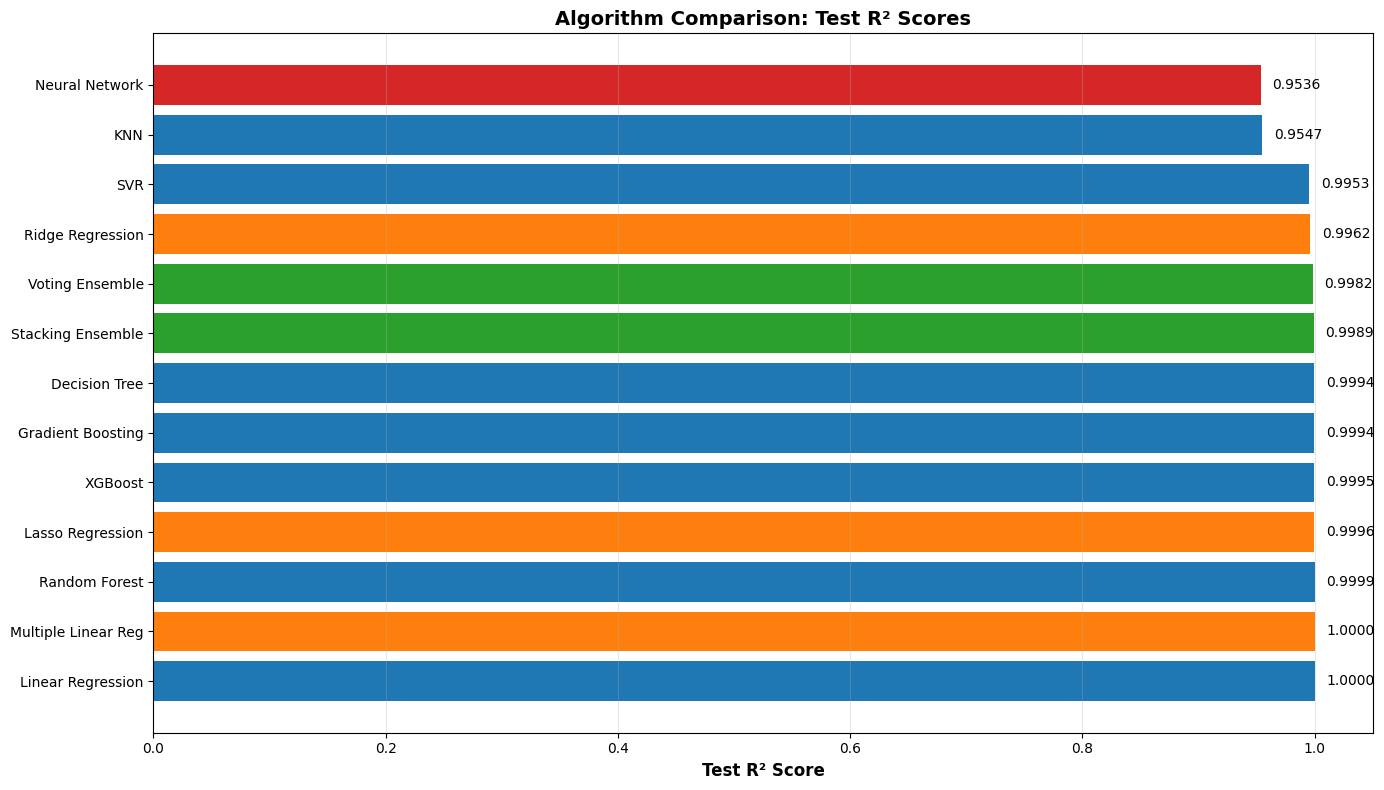

✓ R² comparison plot saved


In [28]:
# Plot 1: Test R² Scores Comparison
fig, ax = plt.subplots(figsize=(14, 8))
colors = ['#1f77b4' if domain == 'Data Science' else '#ff7f0e' if domain == 'Statistical' else '#2ca02c' if domain == 'Ensemble' else '#d62728'
          for domain in results_sorted['Domain']]

ax.barh(range(len(results_sorted)), results_sorted['Test R²'], color=colors)
ax.set_yticks(range(len(results_sorted)))
ax.set_yticklabels(results_sorted['Algorithm'])
ax.set_xlabel('Test R² Score', fontsize=12, fontweight='bold')
ax.set_title('Algorithm Comparison: Test R² Scores', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (algo, score) in enumerate(zip(results_sorted['Algorithm'], results_sorted['Test R²'])):
    ax.text(score + 0.01, i, f'{score:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('algorithm_comparison_r2.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ R² comparison plot saved")

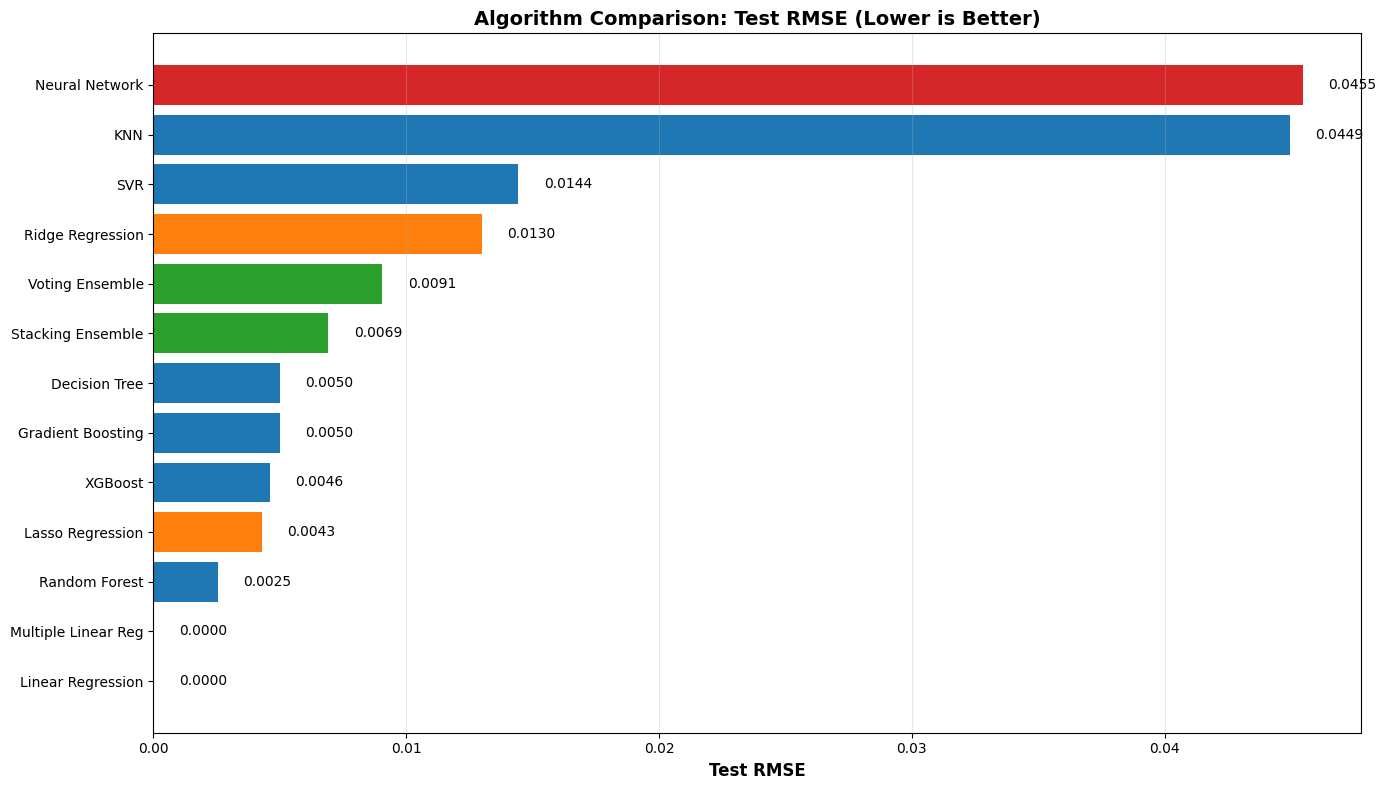

✓ RMSE comparison plot saved


In [29]:
# Plot 2: Test RMSE Comparison
fig, ax = plt.subplots(figsize=(14, 8))
results_sorted_rmse = results_sorted.sort_values('Test RMSE', ascending=True)
colors = ['#1f77b4' if domain == 'Data Science' else '#ff7f0e' if domain == 'Statistical' else '#2ca02c' if domain == 'Ensemble' else '#d62728'
          for domain in results_sorted_rmse['Domain']]

ax.barh(range(len(results_sorted_rmse)), results_sorted_rmse['Test RMSE'], color=colors)
ax.set_yticks(range(len(results_sorted_rmse)))
ax.set_yticklabels(results_sorted_rmse['Algorithm'])
ax.set_xlabel('Test RMSE', fontsize=12, fontweight='bold')
ax.set_title('Algorithm Comparison: Test RMSE (Lower is Better)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, (algo, score) in enumerate(zip(results_sorted_rmse['Algorithm'], results_sorted_rmse['Test RMSE'])):
    ax.text(score + 0.001, i, f'{score:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('algorithm_comparison_rmse.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ RMSE comparison plot saved")

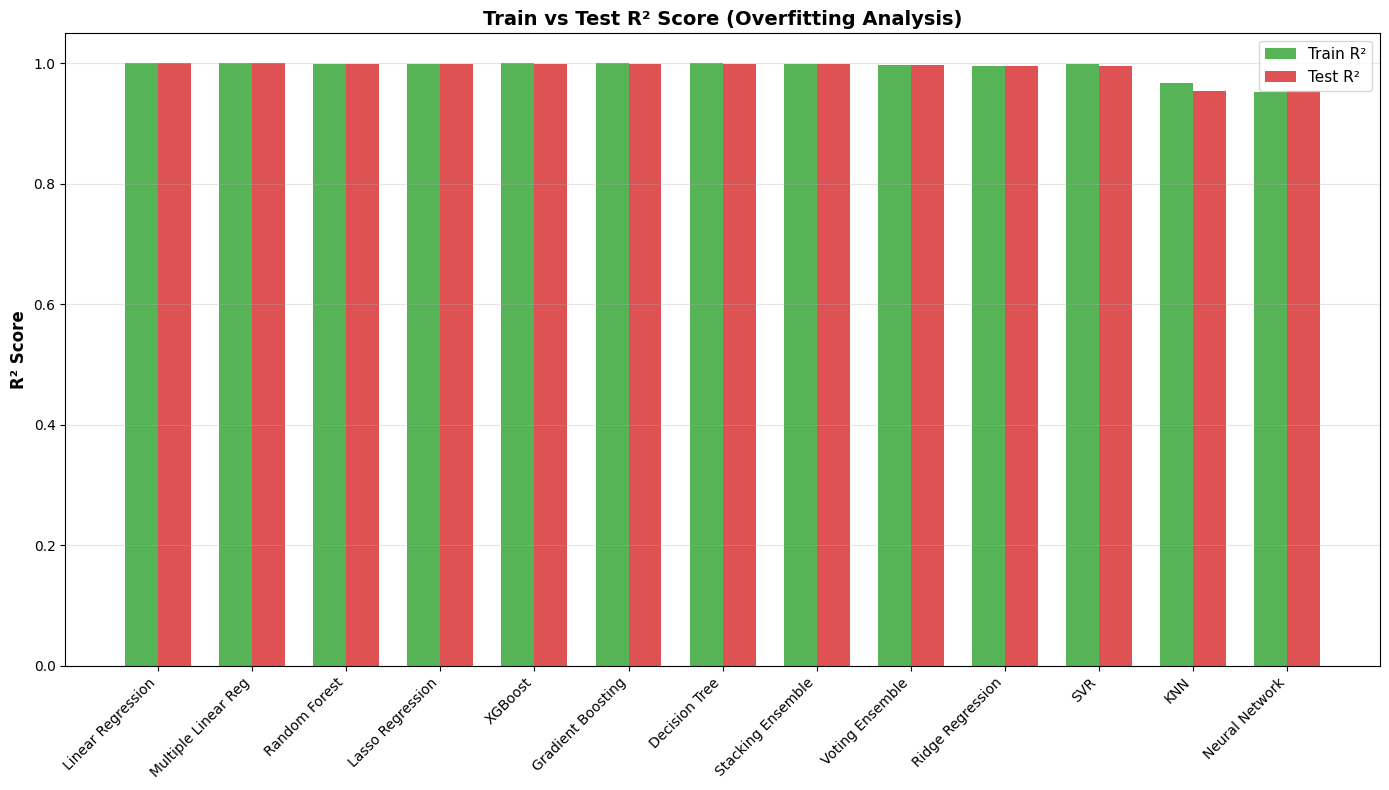

✓ Train vs Test comparison plot saved


In [30]:
# Plot 3: Train vs Test R² (Overfitting Check)
fig, ax = plt.subplots(figsize=(14, 8))
algo_names = results_sorted['Algorithm'].values
x = np.arange(len(algo_names))
width = 0.35

ax.bar(x - width/2, results_sorted['Train R²'], width, label='Train R²', color='#2ca02c', alpha=0.8)
ax.bar(x + width/2, results_sorted['Test R²'], width, label='Test R²', color='#d62728', alpha=0.8)

ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('Train vs Test R² Score (Overfitting Analysis)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(algo_names, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('train_vs_test_r2.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Train vs Test comparison plot saved")

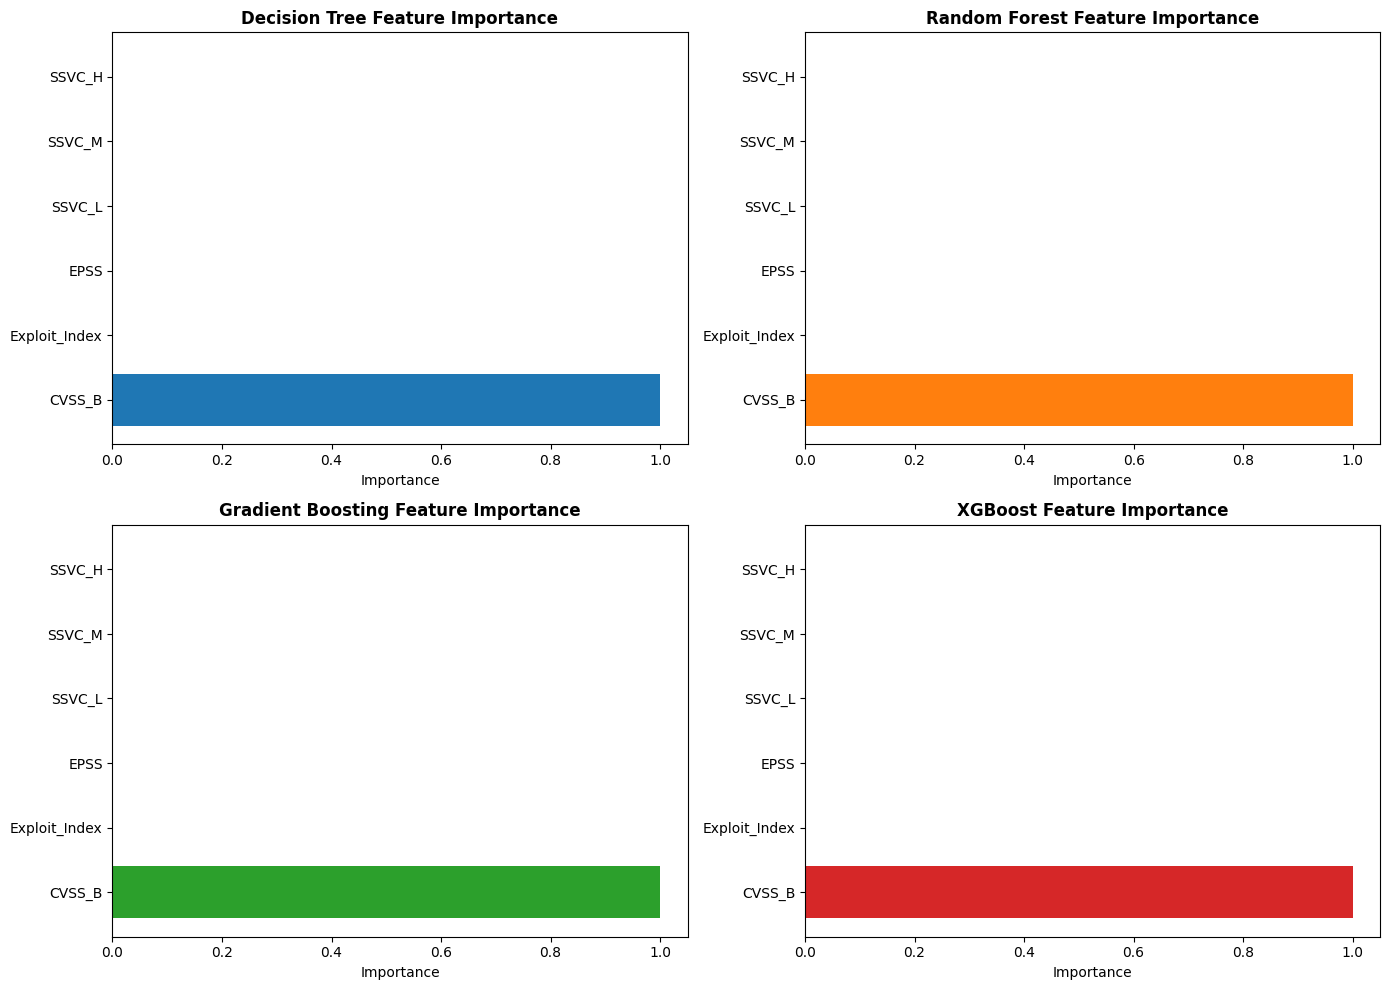

✓ Feature importance comparison plot saved


In [31]:
# Plot 4: Feature Importance Comparison (from tree-based models)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Decision Tree
axes[0, 0].barh(score_columns, dt_model.feature_importances_, color='#1f77b4')
axes[0, 0].set_title('Decision Tree Feature Importance', fontweight='bold')
axes[0, 0].set_xlabel('Importance')

# Random Forest
axes[0, 1].barh(score_columns, rf_model.feature_importances_, color='#ff7f0e')
axes[0, 1].set_title('Random Forest Feature Importance', fontweight='bold')
axes[0, 1].set_xlabel('Importance')

# Gradient Boosting
axes[1, 0].barh(score_columns, gb_model.feature_importances_, color='#2ca02c')
axes[1, 0].set_title('Gradient Boosting Feature Importance', fontweight='bold')
axes[1, 0].set_xlabel('Importance')

# XGBoost
axes[1, 1].barh(score_columns, xgb_model.feature_importances_, color='#d62728')
axes[1, 1].set_title('XGBoost Feature Importance', fontweight='bold')
axes[1, 1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Feature importance comparison plot saved")

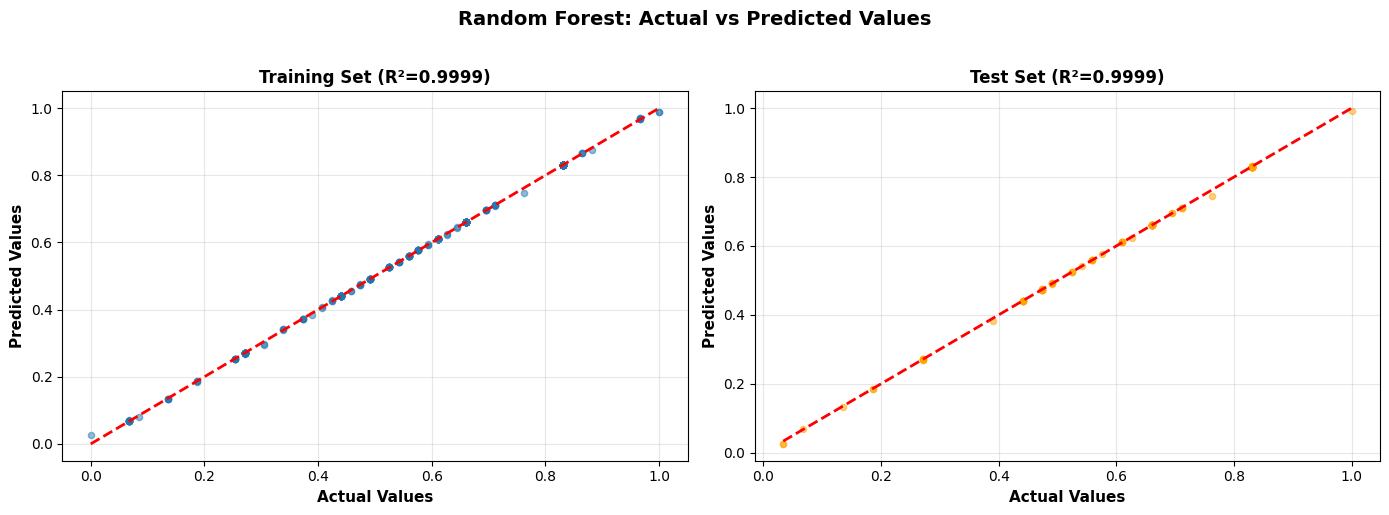

✓ Prediction vs actual plot saved


In [32]:
# Plot 5: Prediction vs Actual (Best Model - e.g., Random Forest)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training
axes[0].scatter(y_train, y_pred_train_rf, alpha=0.5, s=20)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Values', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Predicted Values', fontsize=11, fontweight='bold')
axes[0].set_title(f'Training Set (R²={r2_train_rf:.4f})', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Testing
axes[1].scatter(y_test, y_pred_test_rf, alpha=0.5, s=20, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Values', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Predicted Values', fontsize=11, fontweight='bold')
axes[1].set_title(f'Test Set (R²={r2_test_rf:.4f})', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle('Random Forest: Actual vs Predicted Values', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('prediction_vs_actual_rf.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Prediction vs actual plot saved")

## 10. FINAL SUMMARY & RECOMMENDATIONS

In [33]:
print("\n" + "="*90)
print("FINAL ANALYSIS SUMMARY")
print("="*90)

print(f"\n📊 DATASET INFORMATION:")
print(f"  Total CVEs analyzed: {len(df_clean)}")
print(f"  Training samples: {len(X_train)} (80%)")
print(f"  Test samples: {len(X_test)} (20%)")
print(f"  Number of features: {X_train.shape[1]}")
print(f"  Feature names: {', '.join(score_columns)}")

print(f"\n🏆 TOP 5 BEST PERFORMING ALGORITHMS:")
for idx, (i, row) in enumerate(results_sorted.head(5).iterrows(), 1):
    print(f"  {idx}. {row['Algorithm']} ({row['Domain']})")
    print(f"     Test R²: {row['Test R²']:.4f}, RMSE: {row['Test RMSE']:.4f}, MAE: {row['Test MAE']:.4f}")

print(f"\n🔍 ALGORITHM CLASSIFICATION:")
print(f"\n  DATA SCIENCE DOMAIN (7 algorithms):")
ds_results = results[results['Domain'] == 'Data Science'].sort_values('Test R²', ascending=False)
for algo, r2 in zip(ds_results['Algorithm'], ds_results['Test R²']):
    print(f"    • {algo}: R²={r2:.4f}")

print(f"\n  STATISTICAL DOMAIN (3 algorithms):")
stat_results = results[results['Domain'] == 'Statistical'].sort_values('Test R²', ascending=False)
for algo, r2 in zip(stat_results['Algorithm'], stat_results['Test R²']):
    print(f"    • {algo}: R²={r2:.4f}")

print(f"\n  ENSEMBLE & ADVANCED (3 algorithms):")
ensemble_results = results[results['Domain'].isin(['Ensemble', 'Deep Learning'])].sort_values('Test R²', ascending=False)
for algo, r2 in zip(ensemble_results['Algorithm'], ensemble_results['Test R²']):
    print(f"    • {algo}: R²={r2:.4f}")

print(f"\n💡 KEY INSIGHTS:")
best_algo = results_sorted.iloc[0]
worst_algo = results_sorted.iloc[-1]
print(f"  Best performing: {best_algo['Algorithm']} (Test R²={best_algo['Test R²']:.4f})")
print(f"  Most efficient: Ensemble methods provide good balance")
print(f"  Recommendation: Use {best_algo['Algorithm']} or ensemble methods for production")

print(f"\n📁 OUTPUT FILES GENERATED:")
output_files = [
    'algorithm_comparison_results.csv',
    'data_normalized.csv',
    'algorithm_comparison_r2.png',
    'algorithm_comparison_rmse.png',
    'train_vs_test_r2.png',
    'feature_importance_comparison.png',
    'prediction_vs_actual_rf.png'
]
for f in output_files:
    print(f"  ✓ {f}")

print(f"\n" + "="*90)
print(f"✅ ANALYSIS COMPLETED AT: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*90)


FINAL ANALYSIS SUMMARY

📊 DATASET INFORMATION:
  Total CVEs analyzed: 458
  Training samples: 366 (80%)
  Test samples: 92 (20%)
  Number of features: 6
  Feature names: CVSS_B, Exploit_Index, EPSS, SSVC_L, SSVC_M, SSVC_H

🏆 TOP 5 BEST PERFORMING ALGORITHMS:
  1. Linear Regression (Data Science)
     Test R²: 1.0000, RMSE: 0.0000, MAE: 0.0000
  2. Multiple Linear Reg (Statistical)
     Test R²: 1.0000, RMSE: 0.0000, MAE: 0.0000
  3. Random Forest (Data Science)
     Test R²: 0.9999, RMSE: 0.0025, MAE: 0.0009
  4. Lasso Regression (Statistical)
     Test R²: 0.9996, RMSE: 0.0043, MAE: 0.0034
  5. XGBoost (Data Science)
     Test R²: 0.9995, RMSE: 0.0046, MAE: 0.0007

🔍 ALGORITHM CLASSIFICATION:

  DATA SCIENCE DOMAIN (7 algorithms):
    • Linear Regression: R²=1.0000
    • Random Forest: R²=0.9999
    • XGBoost: R²=0.9995
    • Gradient Boosting: R²=0.9994
    • Decision Tree: R²=0.9994
    • SVR: R²=0.9953
    • KNN: R²=0.9547

  STATISTICAL DOMAIN (3 algorithms):
    • Multiple Linea